In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os
import contextily as ctx

In [3]:
chkd_gdf = gpd.read_file(os.path.join(os.environ['DATA_DIR'], 'chkd_sites/chkd_site_addresses.shp'))
chkd_gdf = chkd_gdf.rename(columns={'HEALTH_CAR': 'HEALTH_CARE_SITE'}).drop(columns='Address')
base_df = pd.read_csv(os.path.join(os.environ['DATA_DIR'], 'Toy Project Outgoing.csv'), low_memory=False, index_col='INDEX_ID')
base_df['PATIENT_ZIPCODE'] = base_df['PATIENT_ZIPCODE'].astype(str).str.zfill(5)

patient_df = chkd_gdf.merge(base_df, on='HEALTH_CARE_SITE', how='right')

In [4]:
patient_df.head()

,HEALTH_CARE_SITE,geometry,DATE_OF_SERVICE,VISIT_TYPE,QUALIFYING_ICD_10_CODE,PATIENT_AGE,PATIENT_RACE,PATIENT_ETHNICITY,PATIENT_GENDER,PATIENT_PERINATAL_EDINBURGH_SCORE,PATIENT_MOST_RECENT_PHQ9_SCORE,MONTH_INTERVAL_BETWEEN_DOS_AND_PHQ9,PATIENT_ZIPCODE,PATIENT_INSURANCE_TYPE
0,CHKD,POINT (-76.30204 36.8622),2018-05-01 01:12:00,Inpatient,J45.901,11,Black or African American,Not Hispanic or Latino,Male,NaN,4,68.9,23606,Commercial
1,CHKD,POINT (-76.30204 36.8622),2018-05-01 00:24:00,Emergency,J06.9,3,Black or African American,Not Hispanic or Latino,Male,NaN,NaN,NaN,23462,Government
2,CHKD,POINT (-76.30204 36.8622),2018-05-01 00:28:00,Emergency,J06.9,1,Black or African American,Not Hispanic or Latino,Male,NaN,NaN,NaN,23462,Government
3,CHKD,POINT (-76.30204 36.8622),2018-05-01 01:27:00,Emergency,J45.901,17,Black or African American,Not Hispanic or Latino,Male,NaN,10,12.1,23509,Government
4,CHKD,POINT (-76.30204 36.8622),2018-05-01 02:55:00,Emergency,J45.901,12,Black or African American,Not Hispanic or Latino,Male,NaN,NaN,NaN,23513,Commercial


In [5]:
patient_df.dissolve(by='HEALTH_CARE_SITE', aggfunc={'DATE_OF_SERVICE': 'count'}).sort_values(by='DATE_OF_SERVICE', ascending=False)

,geometry,DATE_OF_SERVICE
HEALTH_CARE_SITE,,
HC-Loehmann's Plaza,POINT (-76.11106 36.84141),27783
CHKD,POINT (-76.30204 36.8622),27410
UCC-Volvo,POINT (-76.22943 36.76816),23125
HC-Newport News Tech Center,POINT (-76.48665 37.10464),20820
CMG-ChesP-OA,POINT (-76.22414 36.73524),6738
CMG-TCA-Ches,POINT (-76.21859 36.73452),4772
CMG-TCA-Norfolk,POINT (-76.18983 36.84303),4067
CMG-TCA-HV,POINT (-76.44271 36.87153),4021
CMG-PA-Granby,POINT (-76.28317 36.87209),3864


[[], (36.65, 37.2), []]

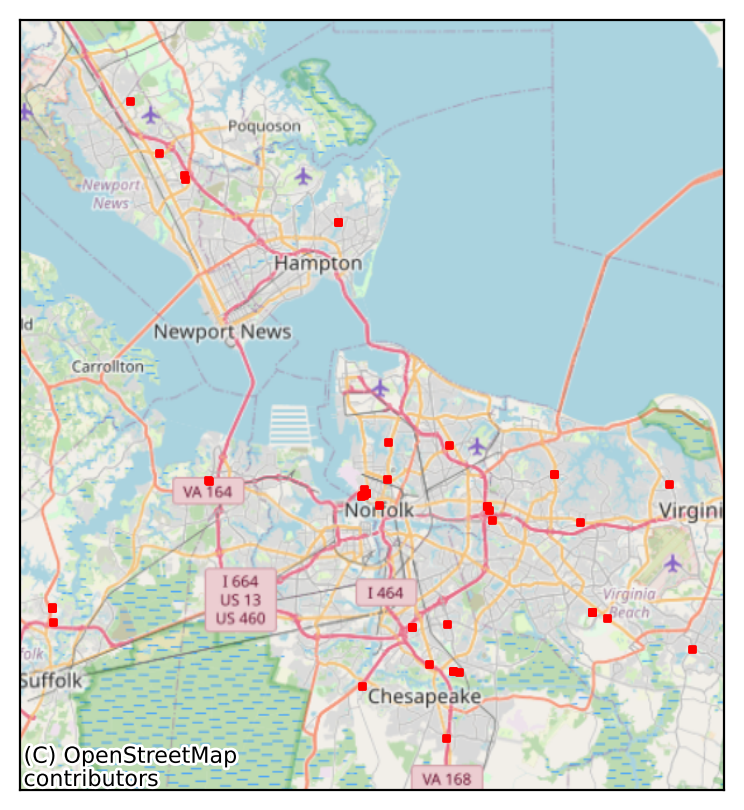

In [44]:
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(6, 5))

# Plot counts at each health care site
site_counts = patient_df.dissolve(by='HEALTH_CARE_SITE', aggfunc={'DATE_OF_SERVICE': 'count'})
#site_counts.plot(ax=ax, column='DATE_OF_SERVICE', markersize=10, edgecolor='black', linewidth=0.5, vmax=5000, legend=False)
site_counts.plot(ax=ax, marker='s', color='red', markersize=5, legend=True)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=patient_df.crs)
ax.set(
    #xlabel='Latitude', 
    #xlim=[-76.7, -75.95],
    xticks=[],
    #ylabel='Longitude', 
    ylim=[36.65, 37.2],
    yticks=[],
)